In [1]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import pandas as pd
from collections import defaultdict
import torch.nn.functional as F


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_GPUS = torch.cuda.device_count()
print(f"Using {NUM_GPUS} GPU(s)")

SEQ_LEN = 5
IMG_SIZE = 192          
BATCH_SIZE = 8       
EPOCHS = 6
LR = 1e-4
HIDDEN_CH = 96
DROPOUT = 0.33

TRAIN_IMG_DIR = "/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/training_videos"
TEST_IMG_DIR  = "/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/testing_videos"



#CSV with all the entries
TEMPLATE_CSV = "/kaggle/input/sample/submission-8.csv"

def extract_frame_number(path):
    return int(os.path.basename(path).split("_")[1].split(".")[0])

def preprocess_frame(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # resize to 192 X 192
    img = cv2.bilateralFilter(img, 5, 75, 75)
    img = img.astype(np.float32) / 255.0 #norm between 0 to 1
    return img 

def unflip_if_needed(img):
    # Fix corrupted vertically flipped frames
    if img[:IMG_SIZE//2].mean() > img[IMG_SIZE//2:].mean():
        return np.flipud(img)
    return img



class AvenuePredictionDataset(Dataset):
    def __init__(self, root):
        self.samples = []

        for vid in sorted(os.listdir(root)):
            paths = sorted(glob.glob(os.path.join(root, vid, "*.jpg")))
            frames = [unflip_if_needed(preprocess_frame(p)) for p in paths]
            frames = np.stack(frames)

            for i in range(SEQ_LEN, len(frames) - 1):
                self.samples.append((frames, i))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frames, i = self.samples[idx]
    
        seq = frames[i-SEQ_LEN:i]            # (T, H, W)
    
        # compute frame differences
        diffs = seq[1:] - seq[:-1]            # (T-1, H, W)
        diffs = np.concatenate(
            [np.zeros_like(diffs[:1]), diffs], axis=0
        )                                     # (T, H, W)
    
        # stack frame + diff as channels
        x = np.stack([seq, diffs], axis=1)    # (T, 2, H, W)
    
        y = frames[i]                         # next frame
        return torch.tensor(x), torch.tensor(y)


class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch):
        super().__init__()
        self.hidden_ch = hidden_ch

        self.conv = nn.Conv2d(
            in_ch + hidden_ch,
            4 * hidden_ch,
            kernel_size=3,
            padding=1
        )
        self.bn = nn.BatchNorm2d(4 * hidden_ch)

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.bn(self.conv(combined))

        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c


class CNNConvLSTMPredictor(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(DROPOUT),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.convlstm = ConvLSTMCell(64, HIDDEN_CH)

        # CNN decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(HIDDEN_CH, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(DROPOUT),

            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
    
        h = torch.zeros(B, HIDDEN_CH, H, W, device=x.device)
        c = torch.zeros_like(h)
    
        for t in range(T):
            feat = self.encoder(x[:, t])   # [B, C, H, W] → [B, 64, H, W]
            h, c = self.convlstm(feat, h, c)
    
        out = self.decoder(h)              # [B, 1, H, W]
        return out

def train():
    dataset = AvenuePredictionDataset(TRAIN_IMG_DIR)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=8,
        pin_memory=True
    )

    model = CNNConvLSTMPredictor().to(DEVICE)
    if NUM_GPUS > 1:
        model = nn.DataParallel(model)
    SAVE_EPOCHS = [1,2,3,4,5,6,7]

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for x, y in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(x)
            loss = loss_fn(pred,y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.6f}")

        if epoch+1 in SAVE_EPOCHS:
            state = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
            torch.save(state, f"model_epoch{epoch+1}.pth")
            print(f"Saved model_epoch{epoch+1}.pth")



if __name__ == "__main__":
    train()

Using 2 GPU(s)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 1/6:   0%|          | 0/1139 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages

Epoch 1 | Loss: 0.006169
Saved model_epoch1.pth


Epoch 2/6:  66%|██████▌   | 750/1139 [07:33<03:55,  1.65it/s]


KeyboardInterrupt: 

In [3]:
def generate_submission():
    # Load template (already has ALL required IDs)
    sample = pd.read_csv(TEMPLATE_CSV)
    sample["Predicted"] = 0.0

    model = CNNConvLSTMPredictor().to(DEVICE)
    model.load_state_dict(torch.load("/kaggle/input/dataset/model_epoch3-2.pth", map_location=DEVICE))
    model.eval()

    score_map = {}
    all_scores = []

    for vid in tqdm(sorted(os.listdir(TEST_IMG_DIR)), desc="Vids"):
        paths = sorted(glob.glob(os.path.join(TEST_IMG_DIR, vid, "*.jpg")))
        frames = [unflip_if_needed(preprocess_frame(p)) for p in paths]
        frames = np.stack(frames)
        frame_nums = [extract_frame_number(p) for p in paths]

        video_fids = []
        video_scores = []

        for i in range(SEQ_LEN, len(frames) - 1):
          
            seq = frames[i-SEQ_LEN:i]
            diffs = seq[1:] - seq[:-1]
            diffs = np.concatenate([np.zeros_like(diffs[:1]), diffs], axis=0)
            x = torch.tensor(np.stack([seq, diffs], axis=1), device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                pred = model(x)[0, 0]
                gt = torch.tensor(frames[i], device=DEVICE)
                err = torch.mean((pred - gt) ** 2).item()

            fid = f"{int(vid)}_{frame_nums[i]}"
            video_fids.append(fid) 
            video_scores.append(err)


        video_scores = pd.Series(video_scores).ewm(alpha=0.6).mean().values
        video_scores[:SEQ_LEN] = 0.0
    

        for fid, score in zip(video_fids, video_scores):
            score_map[fid] = score
            all_scores.append(score)

    # GLOBAL normalization (unchanged)
    mn, mx = min(all_scores), max(all_scores)
    for k in score_map:
        score_map[k] = (score_map[k] - mn) / (mx - mn + 1e-8)

    # Fill into template — missing frames stay 0.0
    for i in range(len(sample)):
        if sample.at[i, "Id"] in score_map:
            sample.at[i, "Predicted"] = score_map[sample.at[i, "Id"]]

    sample.to_csv("0.6_warmup", index=False)
    print("submission.csv generated with EMA smoothing")

if __name__ == "__main__":
    generate_submission()

Vids: 100%|██████████| 21/21 [12:22<00:00, 35.37s/it]


submission.csv generated with EMA smoothing


In [4]:
import pandas as pd

# Load both submissions
ae = pd.read_csv("/kaggle/input/sample/submission-8.csv")
cl = pd.read_csv("/kaggle/input/0-6-warm/0.6_warmup.csv")

# Make sure rows align
assert (ae["Id"] == cl["Id"]).all()

# Weighted fusion
alpha = 0.95
ae["Predicted"] = alpha * cl["Predicted"] + (1 - alpha) * ae["Predicted"]

# Save fused submission
ae.to_csv("sub_lasthope7.csv", index=False) #lol

In [13]:
import os
import cv2
import glob
import numpy as np
import pandas as pd


SUBMISSION_CSV = "/kaggle/input/sub-best/sub_lasthope2.csv"
TEST_IMG_DIR   = "/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/testing_videos"

VIDEO_ID = "10"                 # visualize video 1
VIDEO_DIR = f"{int(VIDEO_ID):02d}"
OUT_VIDEO = "video1_with_scores.mp4"

VIS_SIZE = (640, 360)          # (W, H)
FPS = 11                       # slow enough to inspect


df = pd.read_csv(SUBMISSION_CSV)
score_map = dict(zip(df["Id"], df["Predicted"]))


frames = []
scores = []

paths = sorted(glob.glob(os.path.join(TEST_IMG_DIR, VIDEO_DIR, "*.jpg")))

for p in paths:
    img = cv2.imread(p)
    if img is None:
        continue

    frame_id = int(os.path.basename(p).split("_")[1].split(".")[0])
    key = f"{VIDEO_ID}_{frame_id}"

    score = score_map.get(key, 0.0)

    frames.append(img)
    scores.append(score)

frames = np.array(frames)
scores = np.array(scores)


if len(scores) == 0:
    raise RuntimeError("No scores found — ID mismatch!")


scores_ema = pd.Series(scores).ewm(alpha=0.9).mean().values

# normalize ONLY for visualization
scores_vis = (scores_ema - scores_ema.min()) / (scores_ema.max() - scores_ema.min() + 1e-8)

# thresholds
p90 = np.percentile(scores_vis, 90)
p97 = np.percentile(scores_vis, 97)



fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUT_VIDEO, fourcc, FPS, VIS_SIZE)

for i, (img, score) in enumerate(zip(frames, scores_vis)):
    img = cv2.resize(img, VIS_SIZE)

    # color coding
    if score >= p97:
        color = (0, 0, 255)       # red
        label = "ANOMALY"
    elif score >= p90:
        color = (0, 255, 255)     # yellow
        label = "SUSPICIOUS"
    else:
        color = (0, 255, 0)       # green
        label = "NORMAL"

    # overlay text
    cv2.putText(img, f"Frame: {i}", (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.putText(img, f"Score: {score:.3f}", (15, 65),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.putText(img, label, (15, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # score bar
    bar_len = int(score * 200)
    cv2.rectangle(img, (15, 130), (15 + bar_len, 150), color, -1)
    cv2.rectangle(img, (15, 130), (215, 150), (255, 255, 255), 1)

    out.write(img)

out.release()
print("Saved:", OUT_VIDEO)

✅ Saved: video1_with_scores.mp4


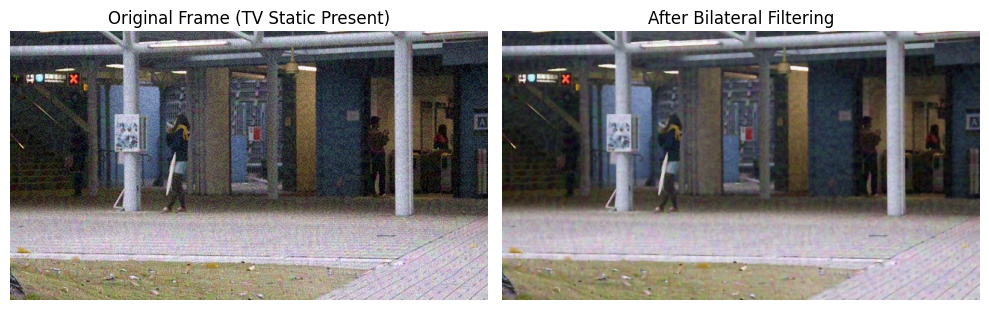

Saved comparison image to tv_static_removal.png


In [4]:
import cv2
import matplotlib.pyplot as plt


IMG_PATH = "/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/training_videos/06/frame_00783.jpg"
OUT_PATH = "tv_static_removal.png"

img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

filtered = cv2.bilateralFilter(
    img,
    d=5,        # neighborhood diameter
    sigmaColor=100,
    sigmaSpace=100
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Frame (TV Static Present)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered)
plt.title("After Bilateral Filtering")
plt.axis("off")

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200)
plt.show()

print(f"Saved comparison image to {OUT_PATH}")

Top half mean intensity    : 76.62
Bottom half mean intensity : 136.34
Difference (bottom - top)  : 59.73


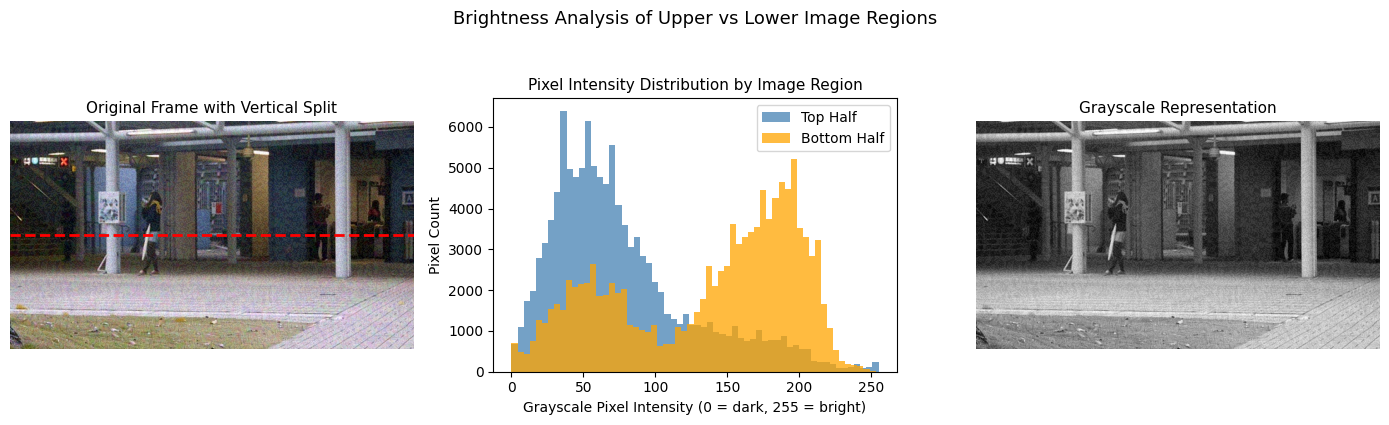

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


IMG_PATH = "/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/training_videos/06/frame_00783.jpg"


img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

H, W = gray.shape
top = gray[:H//2, :]
bottom = gray[H//2:, :]


top_mean = top.mean()
bottom_mean = bottom.mean()

print(f"Top half mean intensity    : {top_mean:.2f}")
print(f"Bottom half mean intensity : {bottom_mean:.2f}")
print(f"Difference (bottom - top)  : {bottom_mean - top_mean:.2f}")


plt.figure(figsize=(14, 4))

# (1) Original image with split
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.axhline(H//2, color='red', linestyle='--', linewidth=2)
plt.title("Original Frame with Vertical Split", fontsize=11)
plt.xlabel("Image Width (pixels)")
plt.ylabel("Image Height (pixels)")
plt.axis("off")

# (2) Intensity histogram
plt.subplot(1, 3, 2)
plt.hist(top.flatten(), bins=60, alpha=0.75, label="Top Half", color="steelblue")
plt.hist(bottom.flatten(), bins=60, alpha=0.75, label="Bottom Half", color="orange")
plt.xlabel("Grayscale Pixel Intensity (0 = dark, 255 = bright)")
plt.ylabel("Pixel Count")
plt.title("Pixel Intensity Distribution by Image Region", fontsize=11)
plt.legend()

# (3) Grayscale visualization
plt.subplot(1, 3, 3)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Representation", fontsize=11)
plt.xlabel("Image Width (pixels)")
plt.ylabel("Image Height (pixels)")
plt.axis("off")

plt.suptitle(
    "Brightness Analysis of Upper vs Lower Image Regions",
    fontsize=13,
    y=1.05
)

plt.tight_layout()
plt.show()

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = CNNConvLSTMPredictor().to(DEVICE)

state = torch.load("/kaggle/input/dataset/model_epoch3-2.pth", map_location=DEVICE)

model.load_state_dict(state)
model.eval()



CNNConvLSTMPredictor(
  (encoder): Sequential(
    (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.33, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
  )
  (convlstm): ConvLSTMCell(
    (conv): Conv2d(160, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): Sequential(
    (0): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.33, inplace=False)
    (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import torch

def visualize_prediction(
    model,
    test_dir,
    video_id,
    seq_len=5,
    device="cuda"
):
    model.eval()

    paths = sorted(glob.glob(os.path.join(test_dir, video_id, "*.jpg")))
    frames = [unflip_if_needed(preprocess_frame(p)) for p in paths]
    frames = np.stack(frames)

    # pick a stable normal region (avoid cold start)
    start = seq_len + 10

    seq = frames[start-seq_len:start]
    gt_next = frames[start]

    diffs = seq[1:] - seq[:-1]
    diffs = np.concatenate([np.zeros_like(diffs[:1]), diffs], axis=0)

    x = torch.tensor(
        np.stack([seq, diffs], axis=1),
        device=device
    ).unsqueeze(0)

    with torch.no_grad():
        pred = model(x)[0, 0].cpu().numpy()

    # 🔥 NEW: anomaly score (same as submission)
    anomaly_score = np.mean((pred - gt_next) ** 2)

    # 🔥 NEW: error map for visualization
    error = np.abs(pred - gt_next)
    error_vis = (error - error.min()) / (error.max() - error.min() + 1e-8)

    fig, axes = plt.subplots(5, seq_len, figsize=(16, 10))

    # Row 1: input frames
    for i in range(seq_len):
        axes[0, i].imshow(seq[i], cmap="gray")
        axes[0, i].set_title(f"Frame {i+1}")
        axes[0, i].axis("off")

    # Row 2: frame differences
    for i in range(seq_len):
        axes[1, i].imshow(np.abs(diffs[i]), cmap="hot")
        axes[1, i].set_title("Frame Diff")
        axes[1, i].axis("off")

    mid = seq_len // 2

    # Row 3: predicted next frame
    axes[2, mid].imshow(pred, cmap="gray")
    axes[2, mid].set_title("Predicted Next Frame")
    axes[2, mid].axis("off")

    # Row 4: ground truth next frame
    axes[3, mid].imshow(gt_next, cmap="gray")
    axes[3, mid].set_title("Ground Truth Next Frame")
    axes[3, mid].axis("off")

    # Row 5: error map + anomaly score
    axes[4, mid].imshow(error_vis, cmap="hot")
    axes[4, mid].set_title(
        f"Error Map | Anomaly Score = {anomaly_score:.5f}"
    )
    axes[4, mid].axis("off")

    # hide unused axes
    for r in [2, 3, 4]:
        for c in range(seq_len):
            if c != mid:
                axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

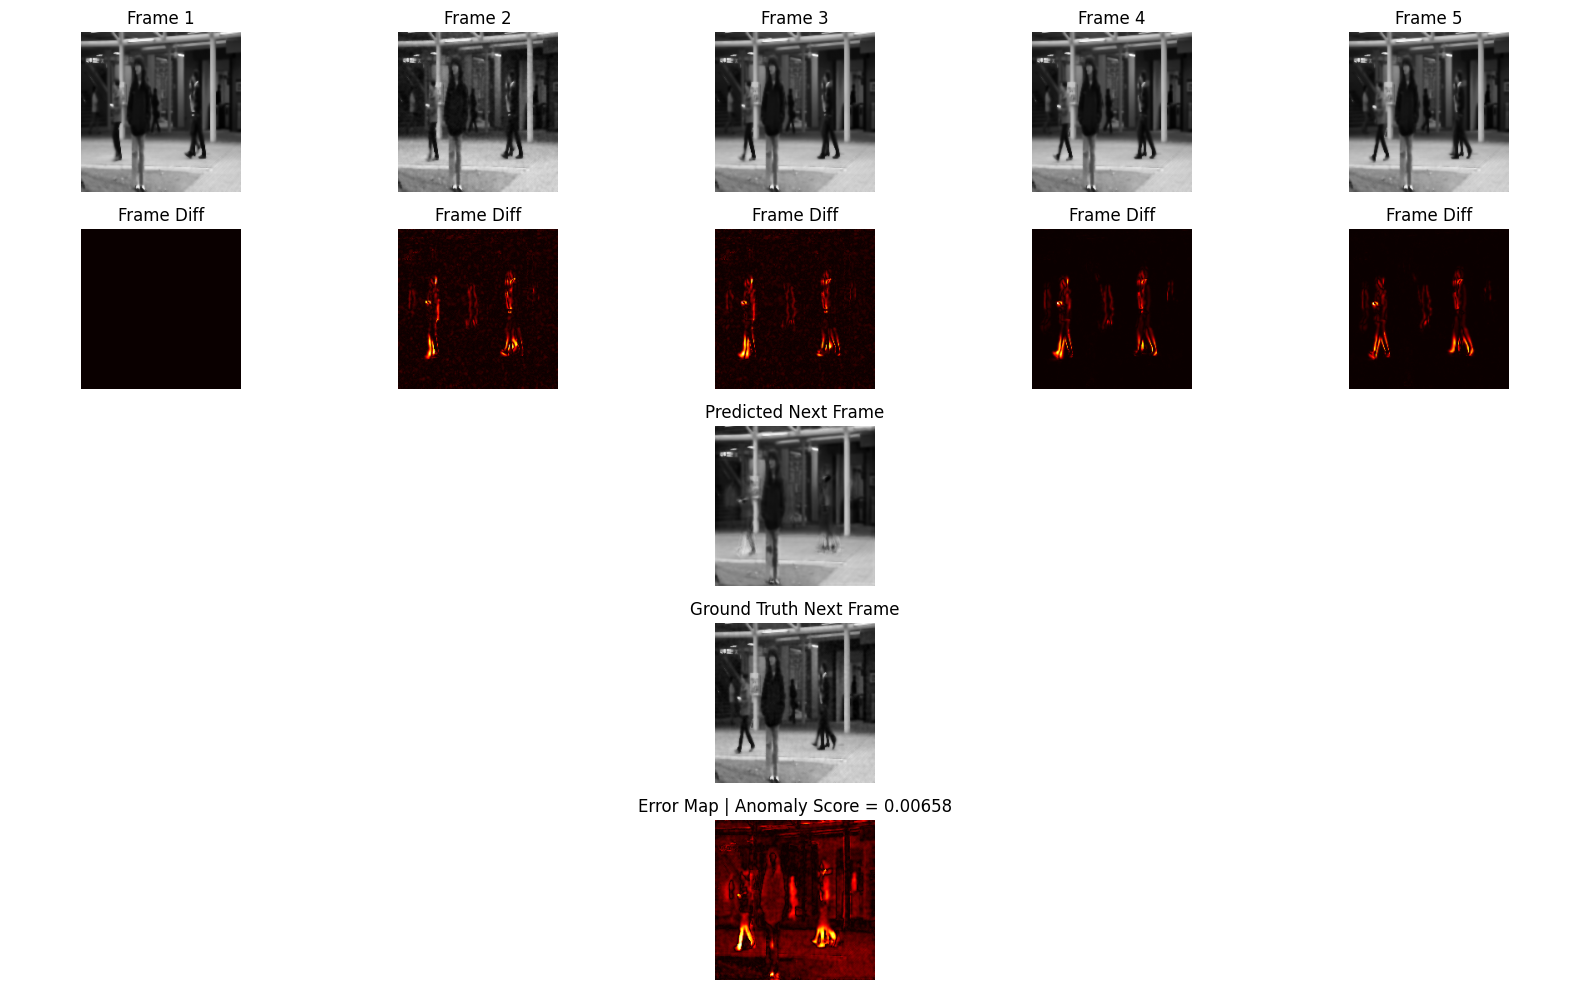

In [28]:
visualize_prediction(
    model=model,
    test_dir=TEST_IMG_DIR,
    video_id="10",  
    seq_len=5,
    device=DEVICE
)

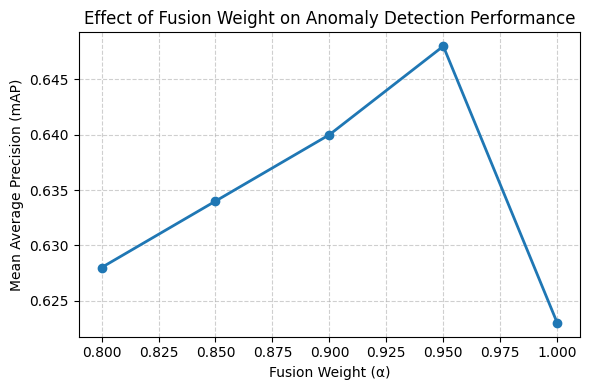

In [3]:
import matplotlib.pyplot as plt

# Fusion weights and corresponding mAP values
alpha = [0.8, 0.85, 0.9, 0.95,1]
map_scores = [0.628, 0.634, 0.64, 0.648,0.623]

plt.figure(figsize=(6,4))
plt.plot(alpha, map_scores, marker='o', linewidth=2)

plt.xlabel("Fusion Weight (α)")
plt.ylabel("Mean Average Precision (mAP)")
plt.title("Effect of Fusion Weight on Anomaly Detection Performance")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

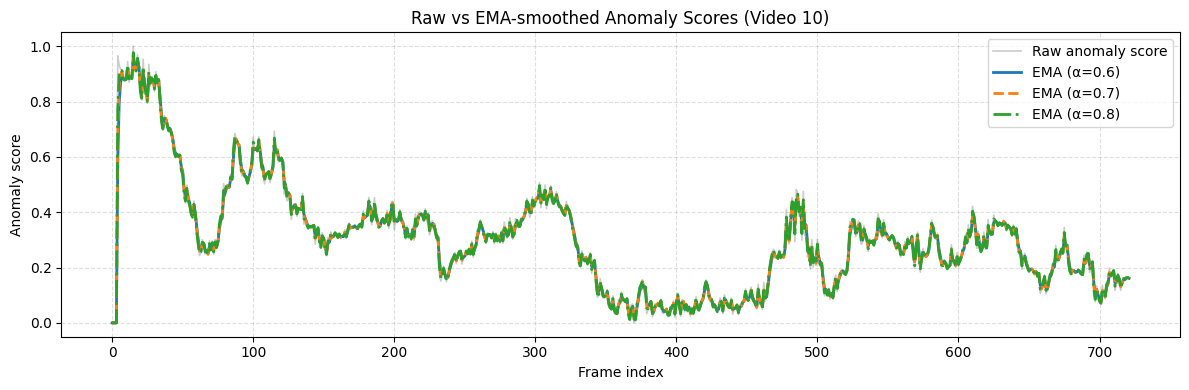

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_raw_vs_multi_ema(csv_path, video_id, alphas=(0.6, 0.7, 0.8)):
    df = pd.read_csv(csv_path)

    video_df = df[df["Id"].str.startswith(f"{video_id}_")].copy()
    video_df["frame"] = video_df["Id"].apply(lambda x: int(x.split("_")[1]))
    video_df = video_df.sort_values("frame")

    raw_scores = video_df["Predicted"].values

    plt.figure(figsize=(12, 4))

    plt.plot(
        raw_scores,
        label="Raw anomaly score",
        color="gray",
        alpha=0.4,
        linewidth=1.2
    )

    linestyles = ["-", "--", "-."]

    for alpha, ls in zip(alphas, linestyles):
        ema_scores = pd.Series(raw_scores).ewm(alpha=alpha).mean().values
        plt.plot(
            ema_scores,
            linewidth=2,
            linestyle=ls,
            label=f"EMA (α={alpha})"
        )

    plt.xlabel("Frame index")
    plt.ylabel("Anomaly score")
    plt.title(f"Raw vs EMA-smoothed Anomaly Scores (Video {video_id})")




    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_raw_vs_multi_ema(
    "/kaggle/input/sample/submission-8.csv",
    video_id="10",
    alphas=(0.6, 0.7, 0.8)
)